# Task 2: Asset Tracking in a Computer Lab using SIFT

**Lab 06 solution**  
Run cells from top to bottom. Change only the paths in the configuration cell when using your own media.

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def show(img, title='', cmap=None, size=(12,7)):
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap or 'gray')
    plt.title(title); plt.axis('off'); plt.show()

## Objective
Recognize a reference asset, such as a monitor or keyboard, inside a scene. SIFT descriptors are matched using FLANN, Lowe's ratio test removes ambiguous matches, and RANSAC homography localizes the asset.

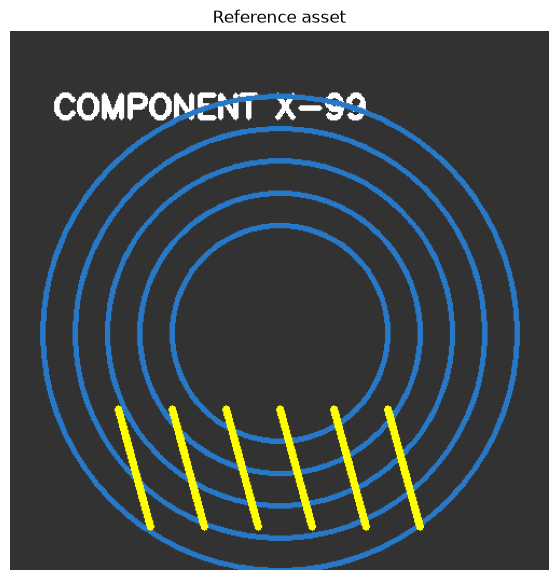

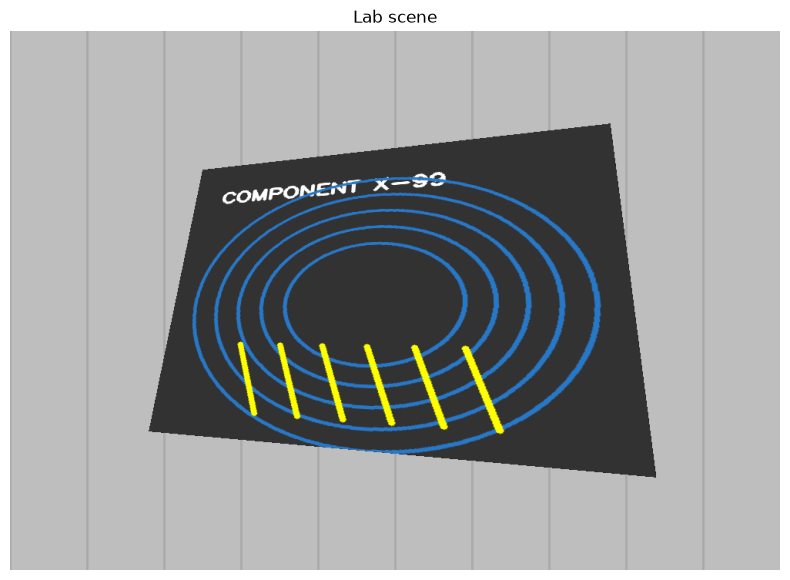

In [7]:
REFERENCE_PATH = 'box.png'
SCENE_PATH = 'box_in_scene.png'

ref = cv.imread(REFERENCE_PATH)
scene = cv.imread(SCENE_PATH)

if ref is None:
    raise FileNotFoundError(f'Could not find {REFERENCE_PATH}')

if scene is None:
    raise FileNotFoundError(f'Could not find {SCENE_PATH}')

show(ref, 'Reference asset')
show(scene, 'Lab scene')

Reference keypoints: 258
Scene keypoints: 484


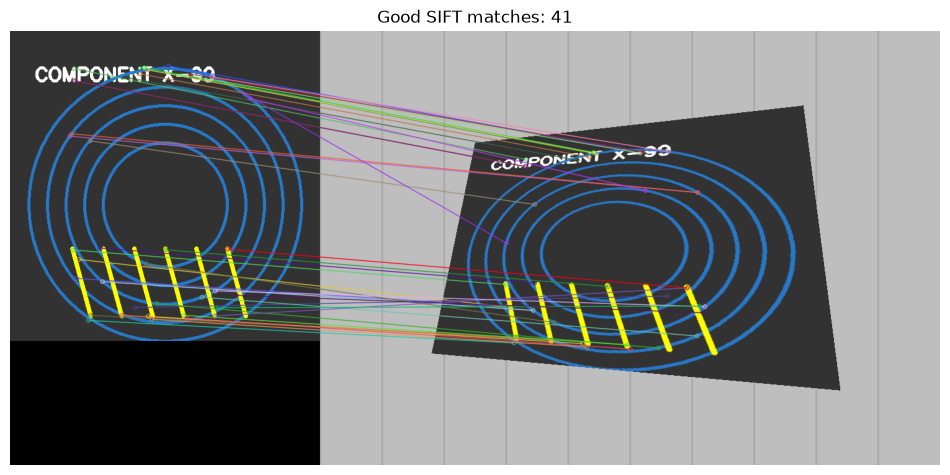

Good SIFT matches: 41


In [8]:
# ============================================================
# SIFT Feature Detection + FLANN Matching
# ============================================================

# Create SIFT detector
sift = cv.SIFT_create(
    nfeatures=2500
)

# Convert images to grayscale
gray_ref = cv.cvtColor(
    ref,
    cv.COLOR_BGR2GRAY
)

gray_scene = cv.cvtColor(
    scene,
    cv.COLOR_BGR2GRAY
)

# ------------------------------------------------------------
# Detect keypoints and descriptors
# ------------------------------------------------------------

kp1, des1 = sift.detectAndCompute(
    gray_ref,
    None
)

kp2, des2 = sift.detectAndCompute(
    gray_scene,
    None
)

# ------------------------------------------------------------
# Validate descriptors
# ------------------------------------------------------------

if des1 is None or len(kp1) < 4:
    raise RuntimeError(
        "Not enough SIFT features in the reference image."
    )

if des2 is None or len(kp2) < 4:
    raise RuntimeError(
        "Not enough SIFT features in the scene image."
    )

print("Reference keypoints:", len(kp1))
print("Scene keypoints:", len(kp2))


# ============================================================
# FLANN-based descriptor matching
# ============================================================

FLANN_INDEX_KDTREE = 1

index_params = dict(
    algorithm=FLANN_INDEX_KDTREE,
    trees=5
)

search_params = dict(
    checks=80
)

flann = cv.FlannBasedMatcher(
    index_params,
    search_params
)

# ------------------------------------------------------------
# K-nearest-neighbour matching
# ------------------------------------------------------------

knn = flann.knnMatch(
    des1,
    des2,
    k=2
)


# ============================================================
# Lowe's ratio test
# ============================================================

good = []

for pair in knn:

    # Some matches may contain fewer than 2 neighbours
    if len(pair) < 2:
        continue

    m, n = pair

    if m.distance < 0.72 * n.distance:
        good.append(m)


# ============================================================
# Display matches
# ============================================================

match_view = cv.drawMatches(
    ref,
    kp1,
    scene,
    kp2,
    good,
    None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

show(
    match_view,
    f"Good SIFT matches: {len(good)}",
    (18, 8)
)

print("Good SIFT matches:", len(good))


# ============================================================
# Check whether there are enough matches for homography
# ============================================================

if len(good) < 4:
    raise RuntimeError(
        f"Only {len(good)} good matches found. "
        "At least 4 are required for homography."
    )


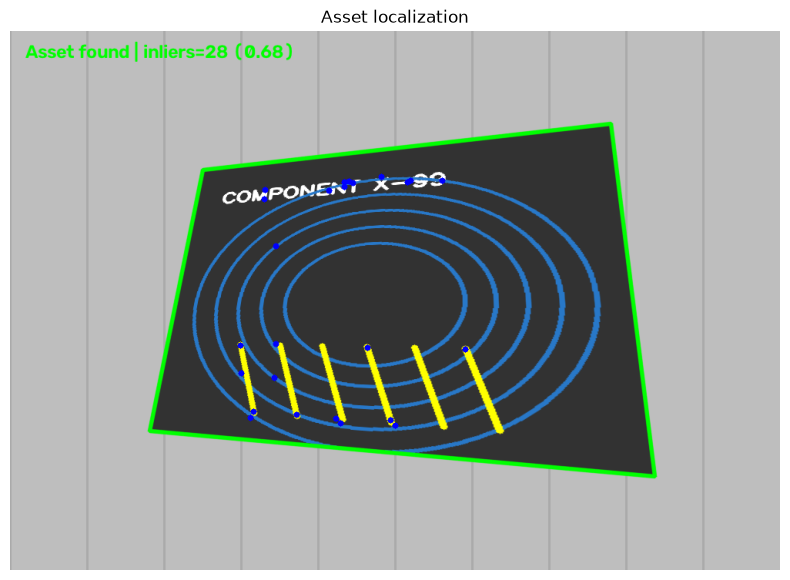

Good matches: 41
RANSAC inliers: 28
Inlier ratio: 0.683


In [9]:
# ============================================================
# Homography + Asset Localization
# ============================================================

result = scene.copy()

# Minimum number of good SIFT matches
MIN_MATCHES = 10

if len(good) < MIN_MATCHES:

    cv.putText(
        result,
        "Asset not found: insufficient reliable matches",
        (20, 35),
        cv.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 0, 255),
        2
    )

else:

    # --------------------------------------------------------
    # Extract matching point coordinates
    # --------------------------------------------------------

    src = np.float32([
        kp1[m.queryIdx].pt
        for m in good
    ]).reshape(-1, 1, 2)

    dst = np.float32([
        kp2[m.trainIdx].pt
        for m in good
    ]).reshape(-1, 1, 2)

    # --------------------------------------------------------
    # Estimate homography using RANSAC
    # --------------------------------------------------------

    H, inliers = cv.findHomography(
        src,
        dst,
        cv.RANSAC,
        5.0
    )

    if H is None or inliers is None:

        cv.putText(
            result,
            "Homography failed",
            (20, 35),
            cv.FONT_HERSHEY_SIMPLEX,
            0.8,
            (0, 0, 255),
            2
        )

    else:

        # ----------------------------------------------------
        # Count RANSAC inliers
        # ----------------------------------------------------

        inlier_mask = inliers.ravel().astype(bool)

        inlier_count = int(
            np.sum(inlier_mask)
        )

        inlier_ratio = (
            inlier_count / float(len(good))
        )

        # ----------------------------------------------------
        # Require a reasonable number of inliers
        # ----------------------------------------------------

        MIN_INLIERS = 8
        MIN_INLIER_RATIO = 0.35

        if (
            inlier_count < MIN_INLIERS
            or inlier_ratio < MIN_INLIER_RATIO
        ):

            cv.putText(
                result,
                (
                    f"Asset not found | "
                    f"inliers={inlier_count} "
                    f"({inlier_ratio:.2f})"
                ),
                (20, 35),
                cv.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 0, 255),
                2
            )

        else:

            # ------------------------------------------------
            # Project reference-image corners into scene
            # ------------------------------------------------

            h, w = ref.shape[:2]

            box = np.float32([
                [0, 0],
                [w - 1, 0],
                [w - 1, h - 1],
                [0, h - 1]
            ]).reshape(-1, 1, 2)

            projected = cv.perspectiveTransform(
                box,
                H
            )

            # Convert to integer coordinates
            projected_int = np.round(
                projected
            ).astype(np.int32)

            # ------------------------------------------------
            # Check projected polygon is reasonable
            # ------------------------------------------------

            scene_h, scene_w = scene.shape[:2]

            points = projected_int.reshape(-1, 2)

            valid_points = np.all(
                np.isfinite(points)
            )

            if valid_points:

                # Polygon area
                polygon_area = abs(
                    cv.contourArea(
                        projected_int
                    )
                )

                scene_area = scene_w * scene_h

                # Reject degenerate or absurd homographies
                valid_polygon = (
                    polygon_area > 100
                    and polygon_area < 1.5 * scene_area
                )

            else:
                valid_polygon = False

            if not valid_polygon:

                cv.putText(
                    result,
                    "Invalid projected asset region",
                    (20, 35),
                    cv.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 0, 255),
                    2
                )

            else:

                # ------------------------------------------------
                # Draw detected asset boundary
                # ------------------------------------------------

                cv.polylines(
                    result,
                    [projected_int],
                    True,
                    (0, 255, 0),
                    4,
                    cv.LINE_AA
                )

                # ------------------------------------------------
                # Draw inlier matches on the scene
                # ------------------------------------------------

                for i, match in enumerate(good):

                    if inlier_mask[i]:

                        x, y = kp2[
                            match.trainIdx
                        ].pt

                        cv.circle(
                            result,
                            (int(x), int(y)),
                            4,
                            (255, 0, 0),
                            -1
                        )

                # ------------------------------------------------
                # Display result information
                # ------------------------------------------------

                text = (
                    f"Asset found | "
                    f"inliers={inlier_count} "
                    f"({inlier_ratio:.2f})"
                )

                cv.putText(
                    result,
                    text,
                    (20, 35),
                    cv.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (0, 255, 0),
                    2
                )


# ============================================================
# Display and save
# ============================================================

show(
    result,
    "Asset localization"
)

cv.imwrite(
    "task2_asset_tracking.jpg",
    result
)

print(
    "Good matches:",
    len(good)
)

if 'inlier_count' in locals():
    print(
        "RANSAC inliers:",
        inlier_count
    )

if 'inlier_ratio' in locals():
    print(
        "Inlier ratio:",
        round(inlier_ratio, 3)
    )


## Decision rule
At least 10 ratio-tested matches are required. RANSAC then rejects geometrically inconsistent matches. A high inlier count and a plausible projected quadrilateral provide stronger evidence than raw match count alone.